In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import missingno


df = pd.read_csv("hf://datasets/dazzle-nu/CIS435-CreditCardFraudDetection/fraudTrain.csv")
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,Unnamed: 23,6006
0,0,1/1/19 0:00,2.703190e+15,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,3495,"Psychologist, counselling",3/9/88,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,NaN,NaN
1,1,1/1/19 0:00,6.304230e+11,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,149,Special educational needs teacher,6/21/78,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,NaN,NaN
2,2,1/1/19 0:00,3.885950e+13,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,4154,Nature conservation officer,1/19/62,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,NaN,NaN
3,3,1/1/19 0:01,3.534090e+15,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,1939,Patent attorney,1/12/67,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,NaN,NaN
4,4,1/1/19 0:03,3.755340e+14,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,99,Dance movement psychotherapist,3/28/86,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,NaN,NaN


In [2]:
df = df.drop(columns=['Unnamed: 0', 'Unnamed: 23', '6006'])

In [3]:
# Split the transaction timestamp into date and time columns.
if "trans_date_trans_time" in df.columns:
    transaction_timestamp = pd.to_datetime(
        df["trans_date_trans_time"],
        format="%m/%d/%y %H:%M"
    )

    df["trans_date"] = transaction_timestamp.dt.date
    df["trans_time"] = transaction_timestamp.dt.time
    df = df.drop(columns=["trans_date_trans_time"])

df[["trans_date", "trans_time"]].head()

,trans_date,trans_time
0,2019-01-01,00:00:00
1,2019-01-01,00:00:00
2,2019-01-01,00:00:00
3,2019-01-01,00:01:00
4,2019-01-01,00:03:00


<Axes: >

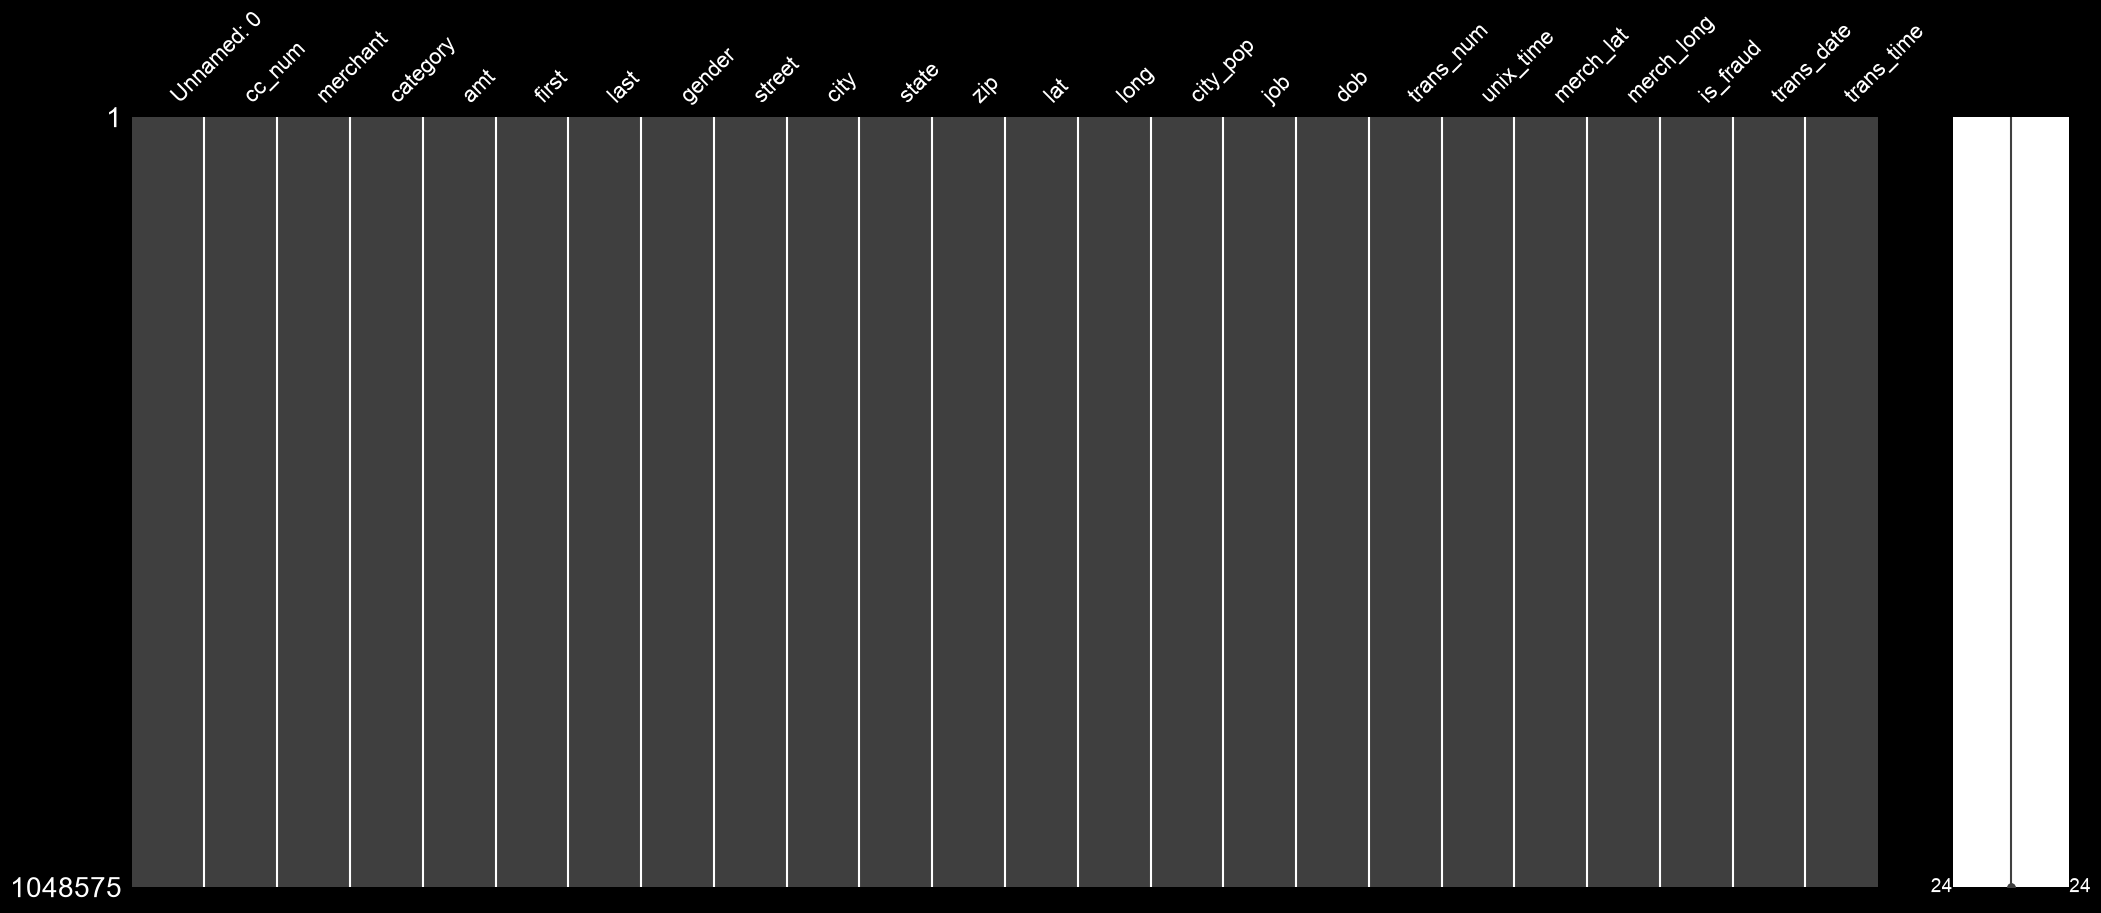

In [4]:
missingno.matrix(df)

In [5]:
duplicate_rows = df[df.duplicated()]
print(len(duplicate_rows))

0


In [6]:
df.columns

Index(['Unnamed: 0', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last',
       'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop',
       'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long',
       'is_fraud', 'trans_date', 'trans_time'],
      dtype='str')

In [7]:
df_isFraud = df[df['is_fraud'] == 1]
print(len(df_isFraud))
df_notFraud = df[df['is_fraud'] == 0]
print(len(df_notFraud))
print("Percentage of fraudulent transactions: {:.2f}%".format(len(df_isFraud) / len(df) * 100))

6006
1042569
Percentage of fraudulent transactions: 0.57%


In [8]:
df_uniqueNames = df['last'].nunique()
print("Number of unique last names: {}".format(df_uniqueNames))
df_isFraud_uniqueNames = df_isFraud['last'].nunique()
print("Number of unique last names in fraudulent transactions: {}".format(df_isFraud_uniqueNames))
df_notFraud_uniqueNames = df_notFraud['last'].nunique()
print("Number of unique last names in non-fraudulent transactions: {}".format(df_notFraud_uniqueNames))

Number of unique last names: 479
Number of unique last names in fraudulent transactions: 365
Number of unique last names in non-fraudulent transactions: 465


In [9]:
df.columns

Index(['Unnamed: 0', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last',
       'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop',
       'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long',
       'is_fraud', 'trans_date', 'trans_time'],
      dtype='str')

In [10]:
unique_years = sorted(pd.to_datetime(df['trans_date']).dt.year.dropna().unique())
print(len(unique_years))

2


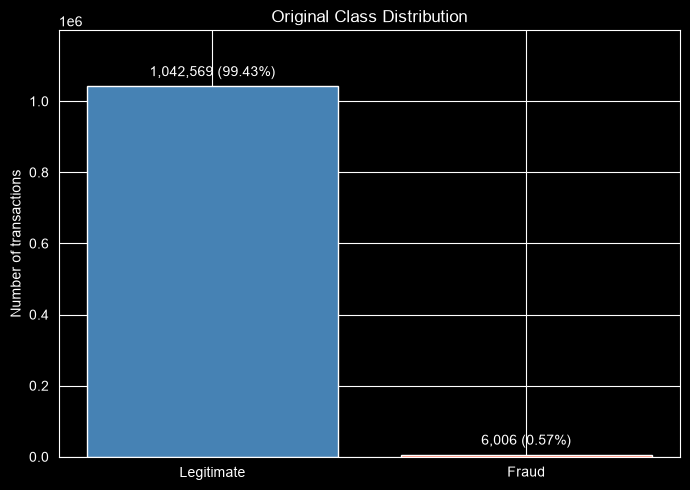

In [11]:
def plot_class_balance(data, title):
    counts = data["is_fraud"].value_counts().reindex([0, 1], fill_value=0)
    percentages = counts / counts.sum() * 100

    fig, ax = plt.subplots(figsize=(7, 5))
    bars = ax.bar(
        ["Legitimate", "Fraud"],
        counts.values,
        color=["steelblue", "tomato"]
    )

    ax.bar_label(
        bars,
        labels=[
            f"{count:,} ({pct:.2f}%)"
            for count, pct in zip(counts, percentages)
        ],
        padding=5
    )
    ax.set(title=title, ylabel="Number of transactions")
    ax.set_ylim(0, counts.max() * 1.15)
    plt.tight_layout()
    plt.show()

plot_class_balance(df, "Original Class Distribution")

Balanced training counts:
is_fraud
0    4805
1    4805
Name: count, dtype: int64


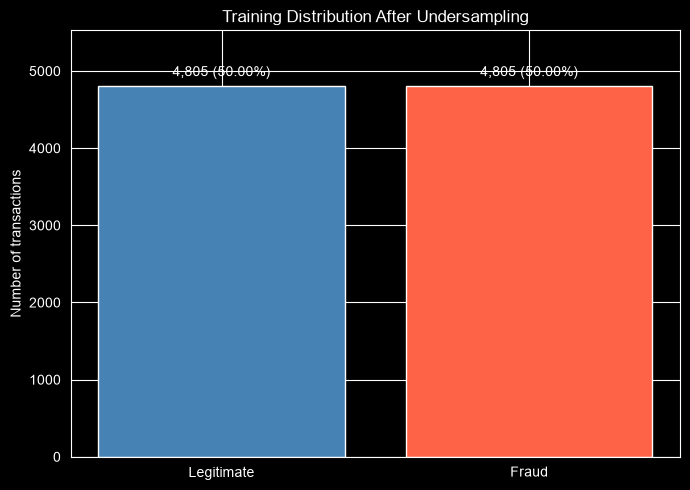

In [12]:
from sklearn.model_selection import train_test_split

# Split before balancing to keep the test set representative.
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["is_fraud"],
    random_state=42
)

# Sample the same number of transactions from each training class.
class_counts = train_df["is_fraud"].value_counts()
samples_per_class = class_counts.min()

train_balanced = pd.concat([
    group.sample(n=samples_per_class, random_state=42)
    for _, group in train_df.groupby("is_fraud")
]).sample(frac=1, random_state=42).reset_index(drop=True)

print("Balanced training counts:")
print(train_balanced["is_fraud"].value_counts().sort_index())

plot_class_balance(train_balanced, "Training Distribution After Undersampling")

# Keep the target out of the input features.
X_train = train_balanced.drop(columns="is_fraud")
y_train = train_balanced["is_fraud"]

X_test = test_df.drop(columns="is_fraud")
y_test = test_df["is_fraud"]

In [18]:
df_isFraud = train_balanced[train_balanced['is_fraud'] == 1]
print(len(df_isFraud))
df_notFraud = train_balanced[train_balanced['is_fraud'] == 0]
print(len(df_notFraud))
print("Percentage of fraudulent transactions: {:.2f}%".format(len(df_isFraud) / len(train_balanced) * 100))

4805
4805
Percentage of fraudulent transactions: 50.00%


In [14]:
df.columns

Index(['Unnamed: 0', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last',
       'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop',
       'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long',
       'is_fraud', 'trans_date', 'trans_time'],
      dtype='str')

In [19]:
train_balanced = train_balanced.sample(frac=1, random_state=42).reset_index(drop=True)


In [22]:
df_isFraud = train_balanced[train_balanced['is_fraud'] == 1]
print(len(df_isFraud))
df_notFraud = train_balanced[train_balanced['is_fraud'] == 0]
print(len(df_notFraud))
print("Percentage of fraudulent transactions: {:.2f}%".format(len(df_isFraud) / len(train_balanced) * 100))

4805
4805
Percentage of fraudulent transactions: 50.00%


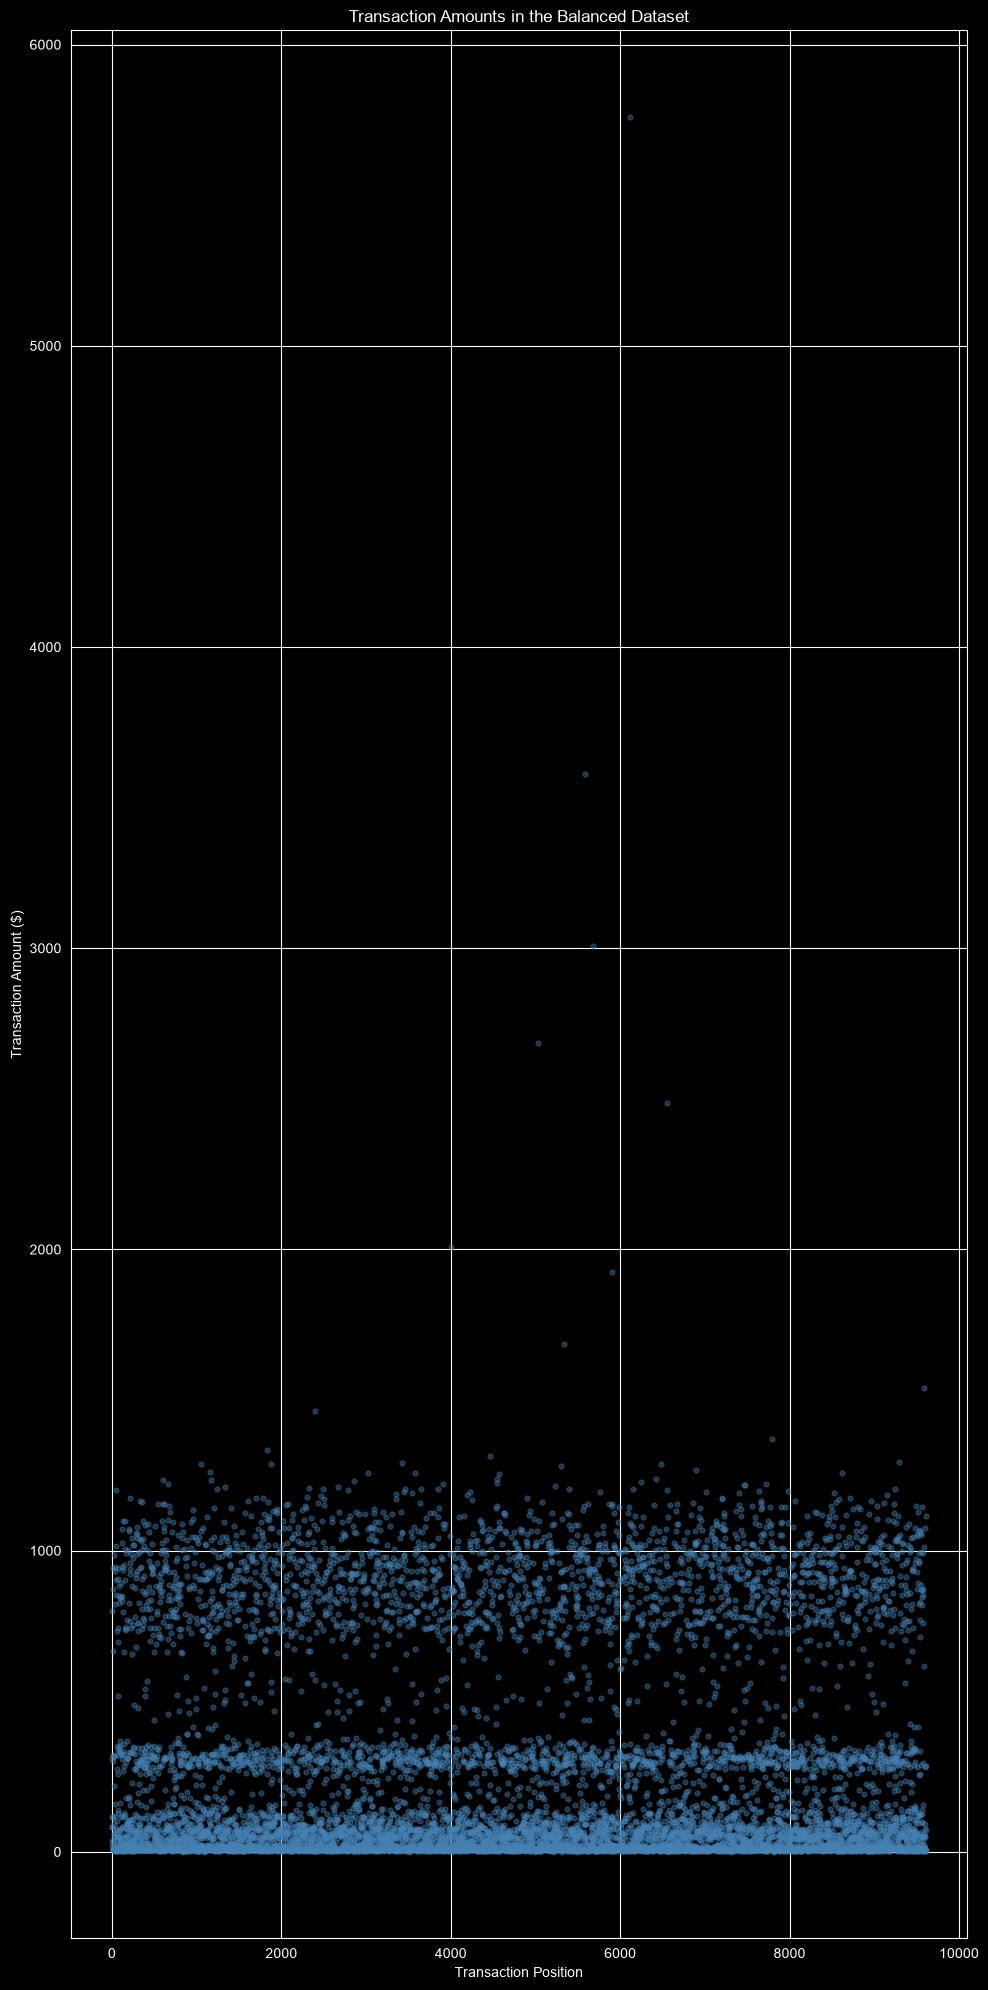

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 20))

plt.scatter(
    range(len(train_balanced)),
    train_balanced["amt"],
    alpha=0.4,
    s=12,
    color="steelblue"
)

plt.title("Transaction Amounts in the Balanced Dataset")
plt.xlabel("Transaction Position")
plt.ylabel("Transaction Amount ($)")
plt.tight_layout()
plt.show()